In [1]:
import pandas as pd

In [46]:
df = pd.read_csv('/content/Advertising.csv')
# df = df[["TV", "sales"]]

In [47]:
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [48]:
df.isnull().sum()

,0
Unnamed: 0,0
TV,0
radio,0
newspaper,0
sales,0


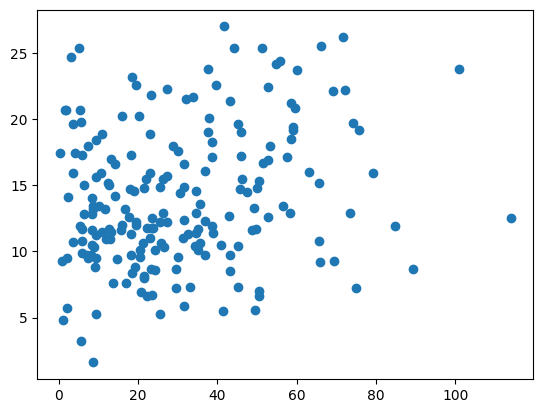

In [51]:
import matplotlib.pyplot as plt
plt.scatter(df["newspaper"], df["sales"])


In [8]:
df.corr()

,TV,sales
TV,1.000000,0.782224
sales,0.782224,1.000000


(array([ 1.,  0.,  0.,  1.,  0.,  0.,  1.,  4.,  2.,  2.,  3.,  6.,  2.,
         6.,  3., 13.,  4., 10.,  7., 13., 11.,  7.,  9.,  5.,  3.,  8.,
         7.,  5.,  6.,  3.,  7.,  3.,  4.,  2.,  6.,  5.,  3.,  4.,  2.,
         3.,  4.,  2.,  1.,  3.,  2.,  1.,  3.,  1.,  1.,  1.]),
 array([ 1.6  ,  2.108,  2.616,  3.124,  3.632,  4.14 ,  4.648,  5.156,
         5.664,  6.172,  6.68 ,  7.188,  7.696,  8.204,  8.712,  9.22 ,
         9.728, 10.236, 10.744, 11.252, 11.76 , 12.268, 12.776, 13.284,
        13.792, 14.3  , 14.808, 15.316, 15.824, 16.332, 16.84 , 17.348,
        17.856, 18.364, 18.872, 19.38 , 19.888, 20.396, 20.904, 21.412,
        21.92 , 22.428, 22.936, 23.444, 23.952, 24.46 , 24.968, 25.476,
        25.984, 26.492, 27.   ]),
 <BarContainer object of 50 artists>)

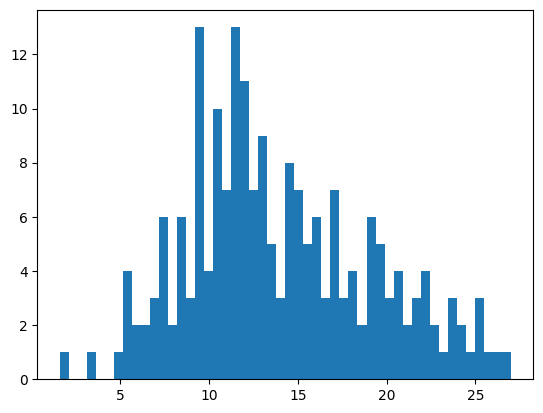

In [10]:
plt.hist(df["sales"], bins=50)

{'whiskers': [<matplotlib.lines.Line2D at 0x7ec8ed66ff50>,
 'caps': [<matplotlib.lines.Line2D at 0x7ec8ed4f4cb0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7ec8ed4c8cb0>],
 'medians': [<matplotlib.lines.Line2D at 0x7ec8ed4c76b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7ec8ed4f1220>],
 'means': []}

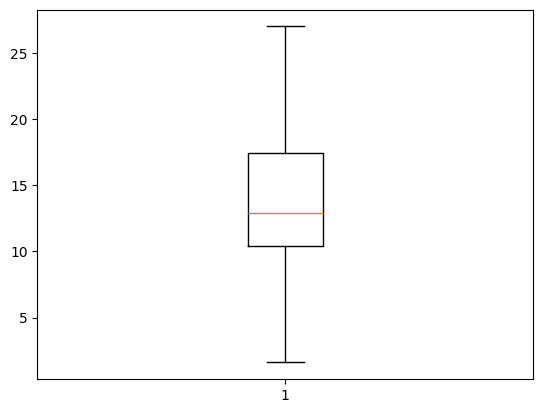

In [11]:
plt.boxplot(df["sales"])

In [12]:
df.describe()

,TV,sales
count,200.000000,200.000000
mean,147.042500,14.022500
std,85.854236,5.217457
min,0.700000,1.600000
25%,74.375000,10.375000
50%,149.750000,12.900000
75%,218.825000,17.400000
max,296.400000,27.000000


In [73]:
x = df.iloc[:, 1:-2]
y = df["sales"]

In [93]:
x.describe()

,TV,radio
count,200.000000,200.000000
mean,147.042500,23.264000
std,85.854236,14.846809
min,0.700000,0.000000
25%,74.375000,9.975000
50%,149.750000,22.900000
75%,218.825000,36.525000
max,296.400000,49.600000


In [94]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x1 = sc.fit_transform(x)

In [19]:
df.shape

(200, 2)

In [95]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x1, y, test_size=0.2, random_state=8)

In [96]:
xtrain.shape

(160, 2)

In [97]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(xtrain, ytrain)

LinearRegression()

In [103]:
round(pd.DataFrame(x1, columns=x.columns).describe(),2)

,TV,radio
count,200.00,200.00
mean,0.00,-0.00
std,1.00,1.00
min,-1.71,-1.57
25%,-0.85,-0.90
50%,0.03,-0.02
75%,0.84,0.90
max,1.74,1.78


In [98]:
pred = lr.predict(xtest)

In [99]:
lr.coef_

array([3.90413172, 2.70112396])

In [100]:
lr.intercept_

np.float64(14.05288939689007)

In [81]:
0.04781615*50+6.93629553999164

9.327103039991641

In [ ]:
sc.transform([[50,10]])

In [113]:
lr.predict(sc.transform([[50,10]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([7.20969485])

In [ ]:
4----2.8

In [84]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [104]:
mean_squared_error(ytest, pred)

4.286861517616688

In [105]:
r2_score(ytest, pred)

0.8471658086135851

In [106]:
r2_score(ytrain, lr.predict(xtrain))

0.9086015041132243

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


ValueError: X has 1 features, but LinearRegression is expecting 2 features as input.

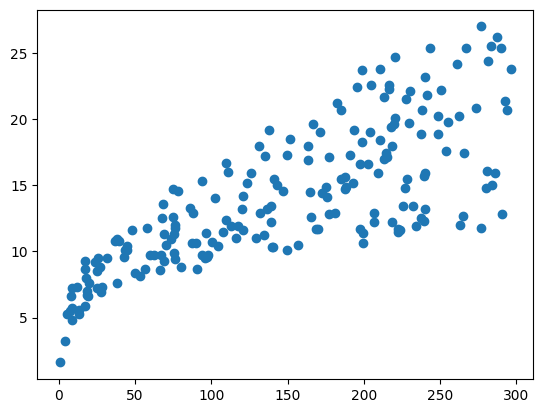

In [107]:
plt.scatter(df["TV"], df["sales"])
plt.plot(df["TV"], lr.predict(df[["TV"]]), color="r")

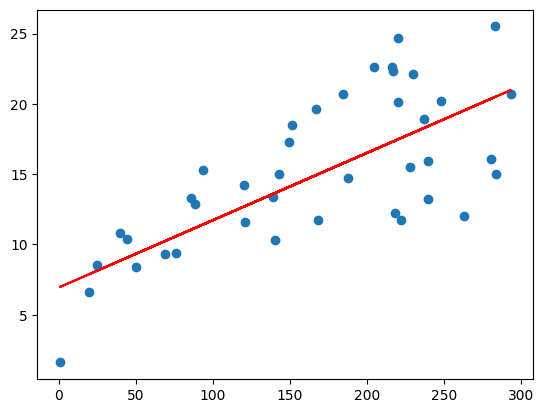

In [30]:
plt.scatter(xtest, ytest)
plt.plot(xtest, pred, color="r")

# High bias low variance model

In [35]:
import statsmodels.formula.api as smf

In [108]:
lm = smf.ols(formula="sales ~ TV + radio", data=df).fit()

In [109]:
lm.conf_int(alpha=0.95)

,0,1
Intercept,2.902610,2.939590
TV,0.045668,0.045842
radio,0.187489,0.188499


In [110]:
lm.conf_int()

,0,1
Intercept,2.340343,3.501857
TV,0.043013,0.048497
radio,0.172139,0.203850


In [111]:
lm.pvalues

,0
Intercept,4.565557e-19
TV,5.436980e-82
radio,9.776972e-59


In [112]:
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     859.6
Date:                Sat, 28 Feb 2026   Prob (F-statistic):           4.83e-98
Time:                        14:54:27   Log-Likelihood:                -386.20
No. Observations:                 200   AIC:                             778.4
Df Residuals:                     197   BIC:                             788.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9211      0.294      9.919      0.000       2.340       3.502
TV             0.0458      0.001     32.909      0.000       0.043       0.048
radio          0.1880      0.008     23.382      0.000       0.172       0.204
==============================================================================
Omnibus:                       60.022   Durbin-Watson:                   2.081
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              148.679
Skew:                          -1.323   Prob(JB):                     5.19e-33
Kurtosis:                       6.292   Cond. No.                         425.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""